In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
#Charger les données Silver
df = pd.read_csv("../data/silver/online_retail_identified.csv")

In [100]:
#Vérifier les données
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [101]:
#Informations dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391169 entries, 0 to 391168
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     391169 non-null  int64  
 1   StockCode     391169 non-null  object 
 2   Description   391169 non-null  object 
 3   Quantity      391169 non-null  float64
 4   InvoiceDate   391169 non-null  object 
 5   UnitPrice     391169 non-null  float64
 6   CustomerID    391169 non-null  int64  
 7   Country       391169 non-null  object 
 8   TotalRevenue  391169 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 26.9+ MB


In [102]:
#Vérifier les nulls
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
TotalRevenue    0
dtype: int64

In [103]:
#Convertir la date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [104]:
#Snapshot Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [105]:
# Vérification de la colonne TotalPrice

if "TotalPrice" not in df.columns:
    df["TotalPrice"] = (
        df["Quantity"] *
        df["UnitPrice"]
    )

print("Colonne TotalPrice disponible")

Colonne TotalPrice disponible


In [106]:
#Créer Snapshot Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [107]:
#Calcul RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [108]:
#Renommer les colonnes
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [109]:
# Remettre CustomerID comme colonne

rfm = rfm.reset_index()

In [110]:
# Vérification

print(rfm.head())

print(rfm.columns)

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1    29.640
1       12347        2          7  3921.635
2       12348       75          4   512.285
3       12349       19          1  1361.350
4       12350      310          1   294.400
Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [111]:
#Afficher le résultat
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,29.640
1,12347,2,7,3921.635
2,12348,75,4,512.285
3,12349,19,1,1361.350
4,12350,310,1,294.400


In [112]:
#Vérifier les statistiques RFM
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000,4334.000000
mean,15299.251731,92.703046,4.245962,1397.837620
std,1721.994109,100.177047,7.634989,3605.506128
min,12346.000000,1.000000,1.000000,3.750000
25%,13812.250000,18.000000,1.000000,262.687500
50%,15297.500000,51.000000,2.000000,586.115000
75%,16778.750000,143.000000,5.000000,1425.397500
max,18287.000000,374.000000,206.000000,115420.820000


In [113]:
#Scoring RFM


#Recency Score:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

#Frequency Score:
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

#Monetary Score:
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)


In [114]:
#Créer le score RFM
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [115]:
#Segmentation Clients
def segment_customer(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'

    elif row['F_score'] >= 4:
        return 'Loyal Customers'

    elif row['R_score'] >= 4:
        return 'Recent Customers'

    elif row['R_score'] <= 2:
        return 'At Risk'

    else:
        return 'Potential Loyalist'

In [116]:
#Appliquer la segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [117]:
#Voir les segments
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346,326,1,29.640,1,1,1,111,At Risk
1,12347,2,7,3921.635,5,5,5,555,Champions
2,12348,75,4,512.285,2,4,3,243,Loyal Customers
3,12349,19,1,1361.350,4,1,4,414,Recent Customers
4,12350,310,1,294.400,1,1,2,112,At Risk


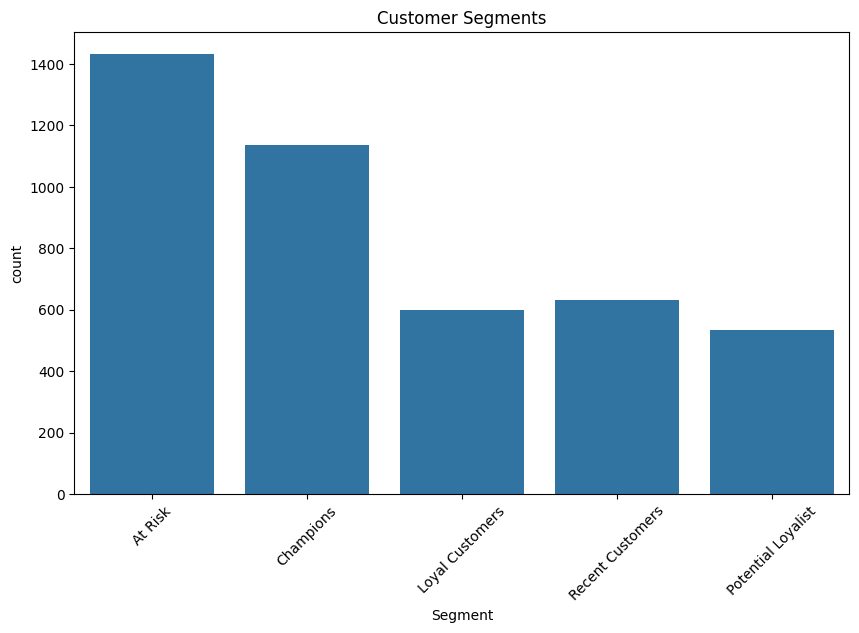

In [118]:
#Visualisation segments
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.xticks(rotation=45)

plt.title("Customer Segments")

plt.show()

In [119]:
#Calcul CLV simple
rfm['CLV'] = (
    rfm['Monetary'] *
    rfm['Frequency']
)

In [120]:
#Top clients
top_customers = rfm.sort_values(
    by='CLV',
    ascending=False
)

top_customers.head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,CLV
1879,14911,1,198,115420.820,5,5,5,555,Champions,2.285332e+07
1689,14646,2,72,91434.300,5,5,5,555,Champions,6.583270e+06
326,12748,1,206,26754.675,5,5,5,555,Champions,5.511463e+06
562,13089,3,97,49430.520,5,5,5,555,Champions,4.794760e+06
4007,17841,2,124,38020.865,5,5,5,555,Champions,4.714587e+06
2176,15311,1,91,34180.135,5,5,5,555,Champions,3.110392e+06
1333,14156,10,54,50505.215,5,5,5,555,Champions,2.727282e+06
4197,18102,1,60,45337.265,5,5,5,555,Champions,2.720236e+06
1434,14298,8,44,39267.335,5,5,5,555,Champions,1.727763e+06
3768,17511,3,31,42610.860,5,5,5,555,Champions,1.320937e+06


In [121]:
#dosssier gold creation
import os

os.makedirs("../data/gold", exist_ok=True)

print("Dossier gold créé")

Dossier gold créé


In [122]:
#Export RFM
rfm.to_csv(
    "../data/gold/rfm_customers.csv",
    index=False
)

In [123]:
#Export CLV
top_customers.to_csv(
    "../data/gold/clv_customers.csv",
    index=False
)

In [124]:
# Création des KPIs business
kpis = pd.DataFrame({

    'Total_Revenue': [df['TotalPrice'].sum()],

    'Average_Order_Value': [df['TotalPrice'].mean()],

    'Total_Customers': [df['CustomerID'].nunique()]
})

In [125]:
# Export KPI Dataset
kpis.to_csv(
    "../data/gold/kpi_sales.csv",
    index=False
)

In [126]:
# Final Verification

print("L3 completed successfully")

L3 completed successfully
